# 02 — Semantic Segmentation: PlantVillage Leaf Disease

Pixel-level segmentation of PlantVillage leaf images into **3 classes**:
background, healthy leaf tissue, and diseased tissue.

In [1]:
# Install dependencies and download dataset
!pip install -q segmentation-models-pytorch albumentations
!pip install -q datasets torch torchvision opencv-python matplotlib seaborn tqdm
!pip install -q kaggle
!kaggle datasets download -d abdallahalidev/plantvillage-dataset --unzip -p /content/plantvillage

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:16<00:00, 137MB/s]



In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, glob, random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

import segmentation_models_pytorch as smp
import albumentations as A

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
print(f'Device: {DEVICE}  |  AMP: {USE_AMP}')

Device: cuda  |  AMP: True


In [5]:
# ── Configuration ────────────────────────────────────────────────────────────
CONFIG = {
    'image_size':    256,
    'batch_size':    64,
    'phase1_epochs': 5,
    'phase2_epochs': 10,
    'base_lr':       1e-4,
    'num_classes':   3,
    'encoder':       'mobilenet_v2',
    'seed':          42,
    'save_dir':      '/content/runs/segmentation',
}

DATA_COLOR = '/content/plantvillage/plantvillage dataset/color'
DATA_SEG   = '/content/plantvillage/plantvillage dataset/segmented'

random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
os.makedirs(CONFIG['save_dir'], exist_ok=True)

print('Config:', CONFIG)

Config: {'image_size': 256, 'batch_size': 64, 'phase1_epochs': 5, 'phase2_epochs': 10, 'base_lr': 0.0001, 'num_classes': 3, 'encoder': 'mobilenet_v2', 'seed': 42, 'save_dir': '/content/runs/segmentation'}


## 1. Ground-truth mask generation & paired file discovery

In [3]:
# ── Tri-class mask from colour + segmented pair ──────────────────────────────

def _largest_component(binary_mask):
    """Keep only the largest connected component."""
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary_mask, connectivity=8
    )
    if num_labels <= 1:
        return binary_mask
    largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    return np.where(labels == largest, 255, 0).astype(np.uint8)


def build_triclass_mask(color_bgr, seg_bgr):
    """
    Build a (H, W) mask with class labels:
        0 = background, 1 = healthy leaf, 2 = disease.

    Parameters
    ----------
    color_bgr : np.ndarray  – colour image in BGR (from cv2.imread)
    seg_bgr   : np.ndarray  – segmented image in BGR
    """
    # ---- Leaf mask from the segmented image (non-black pixels) ----
    seg_rgb   = cv2.cvtColor(seg_bgr, cv2.COLOR_BGR2RGB)
    leaf_mask = (seg_rgb.max(axis=2) > 20).astype(np.uint8) * 255
    kernel    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    leaf_mask = _largest_component(leaf_mask)

    # ---- Healthy-tissue mask from colour image (strict green HSV) ----
    hsv = cv2.cvtColor(color_bgr, cv2.COLOR_BGR2HSV)
    lower_healthy = np.array([30, 50, 40])
    upper_healthy = np.array([85, 255, 255])
    healthy_mask  = cv2.inRange(hsv, lower_healthy, upper_healthy)
    healthy_mask  = cv2.bitwise_and(healthy_mask, healthy_mask, mask=leaf_mask)

    # ---- Compose tri-class mask ----
    mask = np.zeros(leaf_mask.shape, dtype=np.int64)   # 0 = background
    mask[leaf_mask > 0]    = 2                          # leaf but not healthy → disease
    mask[healthy_mask > 0] = 1                          # healthy leaf

    return mask

print('build_triclass_mask() defined.')

build_triclass_mask() defined.


In [4]:
# ── Discover paired files (colour ↔ segmented) ──────────────────────────────
class_names = sorted(os.listdir(DATA_COLOR))

color_paths, seg_paths, labels = [], [], []

for cls in class_names:
    color_dir = os.path.join(DATA_COLOR, cls)
    seg_dir   = os.path.join(DATA_SEG,   cls)

    if not os.path.isdir(seg_dir):
        continue

    # Iterar sobre os arquivos na pasta de imagens coloridas originais
    for color_fname in os.listdir(color_dir):

        # Ignorar arquivos ocultos ou que não sejam imagens (opcional, mas recomendado)
        if not color_fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        # Extrair o nome base separando a extensão (ex: tira o ".JPG")
        base_name, _ = os.path.splitext(color_fname)

        # Construir o nome do arquivo segmentado esperado
        seg_fname = f"{base_name}_final_masked.jpg"
        seg_path = os.path.join(seg_dir, seg_fname)

        # Verificar se o par segmentado realmente existe na pasta
        if os.path.exists(seg_path):
            color_paths.append(os.path.join(color_dir, color_fname))
            seg_paths.append(seg_path)
            labels.append(cls)

print(f'Total paired samples: {len(color_paths):,}')
print(f'Classes found: {len(set(labels))}')

# ── Stratified train / val split (80/20) ─────────────────────────────────────
# Adicionado um 'if' de segurança para evitar que o erro quebre o notebook novamente
if len(color_paths) > 0:
    idx = list(range(len(color_paths)))
    train_idx, val_idx = train_test_split(
        idx, test_size=0.2, stratify=labels, random_state=CONFIG['seed']
    )

    train_color = [color_paths[i] for i in train_idx]
    train_seg   = [seg_paths[i]   for i in train_idx]
    val_color   = [color_paths[i] for i in val_idx]
    val_seg     = [seg_paths[i]   for i in val_idx]

    print(f'Train: {len(train_color):,}  |  Val: {len(val_color):,}')
else:
    print("Nenhum par encontrado. Verifique os caminhos ou os nomes dos arquivos.")

Total paired samples: 53,109
Classes found: 37
Train: 42,487  |  Val: 10,622


## 2. Dataset

In [9]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# 1. Pastas de destino para o dataset otimizado
DEST_DIR = '/content/plantvillage_fast'
os.makedirs(os.path.join(DEST_DIR, 'images'), exist_ok=True)
os.makedirs(os.path.join(DEST_DIR, 'masks'), exist_ok=True)

def create_mini_dataset(color_paths, seg_paths, split_name):
    print(f"Processando {split_name} no disco...")

    new_img_paths = []
    new_mask_paths = []

    for i in tqdm(range(len(color_paths))):
        img_name = f"{split_name}_{i}.jpg"
        mask_name = f"{split_name}_{i}.png"

        img_dest = os.path.join(DEST_DIR, 'images', img_name)
        mask_dest = os.path.join(DEST_DIR, 'masks', mask_name)

        # Só processa se a máscara otimizada ainda não existir no disco
        if not os.path.exists(mask_dest):
            color_bgr = cv2.imread(color_paths[i])
            seg_bgr   = cv2.imread(seg_paths[i])

            # O cálculo pesado acontece AQUI, apenas uma vez!
            mask = build_triclass_mask(color_bgr, seg_bgr)

            # Copia a imagem original (já é 256x256) e salva a máscara calculada
            cv2.imwrite(img_dest, color_bgr)
            cv2.imwrite(mask_dest, mask)

        new_img_paths.append(img_dest)
        new_mask_paths.append(mask_dest)

    return new_img_paths, new_mask_paths

# 2. CRIA AS VARIÁVEIS PARA O DATALOADER
print("Preparando conjunto de treino...")
train_color_256, train_seg_256 = create_mini_dataset(train_color, train_seg, "train")

print("Preparando conjunto de validação...")
val_color_256, val_seg_256     = create_mini_dataset(val_color, val_seg, "val")

print("\nVariáveis criadas! Pode rodar a célula do seu DataLoader agora.")

Preparando conjunto de treino...
Processando train no disco...


100%|██████████| 42487/42487 [05:58<00:00, 118.62it/s]


Preparando conjunto de validação...
Processando val no disco...


100%|██████████| 10622/10622 [01:27<00:00, 120.94it/s]


Variáveis criadas! Pode rodar a célula do seu DataLoader agora.


In [14]:
class FastDiskSegDataset(Dataset):
    def __init__(self, color_paths, mask_paths): # Removido o parâmetro augmentation
        self.color_paths  = color_paths
        self.mask_paths   = mask_paths

    def __len__(self):
        return len(self.color_paths)

    def __getitem__(self, i):
        # 1. Leitura rápida do disco (já em 256x256)
        image = cv2.imread(self.color_paths[i])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 2. Leitura da máscara (já com classes 0, 1, 2)
        mask = cv2.imread(self.mask_paths[i], cv2.IMREAD_GRAYSCALE)

        # 3. Direto para Tensor (Sem Albumentations)
        image = torch.from_numpy(image).float().permute(2, 0, 1) / 255.0
        mask  = torch.from_numpy(np.asarray(mask)).long()

        return image, mask

In [15]:
# ── DataLoaders ──────────────────────────────────────────────────────────────
# Passamos apenas as listas de caminhos criadas no passo anterior
train_ds = FastDiskSegDataset(train_color_256, train_seg_256)
val_ds   = FastDiskSegDataset(val_color_256, val_seg_256)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
                          num_workers=2, pin_memory=True)

val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)

# Quick sanity check (Excelente iniciativa!)
imgs, masks = next(iter(train_loader))
print(f'Batch images : {imgs.shape}  (dtype={imgs.dtype})')
print(f'Batch masks  : {masks.shape}  (dtype={masks.dtype})')
print(f'Mask classes  : {sorted(masks.unique().tolist())}')

Batch images : torch.Size([64, 3, 256, 256])  (dtype=torch.float32)
Batch masks  : torch.Size([64, 256, 256])  (dtype=torch.int64)
Mask classes  : [0, 1, 2]


## 3. Model: U-Net + MobileNetV2

In [16]:
# ── Model ────────────────────────────────────────────────────────────────────
model = smp.Unet(
    encoder_name=CONFIG['encoder'],
    encoder_weights='imagenet',
    in_channels=3,
    classes=CONFIG['num_classes'],
)
model.to(DEVICE)

total_params   = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = total_params - encoder_params
print(f'Total params   : {total_params:,}')
print(f'Encoder params : {encoder_params:,}')
print(f'Decoder params : {decoder_params:,}')

Total params   : 6,629,235
Encoder params : 2,223,872
Decoder params : 4,405,363


## 4. Loss function, optimiser & training loop

In [17]:
# ── Loss: Dice + Cross-Entropy (handles class imbalance at pixel level) ─────
dice_loss = smp.losses.DiceLoss(mode='multiclass')
ce_loss   = nn.CrossEntropyLoss()

def combined_loss(pred, target):
    return dice_loss(pred, target) + ce_loss(pred, target)

print('Combined Dice + CE loss defined.')

Combined Dice + CE loss defined.


In [18]:
# ── Training & validation helpers ────────────────────────────────────────────

# Passando DEVICE.type para evitar alertas de depreciação do PyTorch
scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0

    for images, masks in tqdm(loader, desc='  train', leave=False):
        # non_blocking=True paraleliza a cópia da RAM para a VRAM (se pin_memory=True no DataLoader)
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE, non_blocking=True)

        # set_to_none=True é mais rápido e economiza memória do que definir os gradientes como 0
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            preds = model(images)
            loss  = combined_loss(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss = 0.0

    for images, masks in tqdm(loader, desc='  val  ', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            preds = model(images)
            loss  = combined_loss(preds, masks)

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

print('Training helpers defined with max optimizations.')

Training helpers defined with max optimizations.


In [20]:
# ── Phase 1: Freeze encoder — train decoder only ────────────────────────────
for p in model.encoder.parameters():
    p.requires_grad = False

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                  lr=CONFIG['base_lr'])
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['phase1_epochs'])

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
best_model_path = os.path.join(CONFIG['save_dir'], 'best_seg_model.pth')

print(f'=== Phase 1: {CONFIG["phase1_epochs"]} epochs (encoder frozen) ===')
for epoch in range(1, CONFIG['phase1_epochs'] + 1):

    # Chamada corrigida: passamos apenas o modelo, o loader e o otimizador.
    # O DEVICE e o scaler já estão sendo puxados globalmente pelo seu helper!
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss   = validate(model, val_loader)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    tag = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        tag = ' ★ saved'

    print(f'  Epoch {epoch}/{CONFIG["phase1_epochs"]}  '
          f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}{tag}')

=== Phase 1: 5 epochs (encoder frozen) ===


  Epoch 1/5  train_loss=0.4499  val_loss=0.2668 ★ saved


  Epoch 2/5  train_loss=0.2557  val_loss=0.2261 ★ saved


  Epoch 3/5  train_loss=0.2303  val_loss=0.2119 ★ saved


  Epoch 4/5  train_loss=0.2162  val_loss=0.2060 ★ saved


  Epoch 5/5  train_loss=0.2090  val_loss=0.2019 ★ saved


In [21]:
# ── Phase 2: Unfreeze all — fine-tune with lower LR ─────────────────────────
for p in model.encoder.parameters():
    p.requires_grad = True

optimizer = AdamW(model.parameters(), lr=CONFIG['base_lr'] / 10)
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['phase2_epochs'])

print(f'\n=== Phase 2: {CONFIG["phase2_epochs"]} epochs (all layers unfrozen, LR /10) ===')
for epoch in range(1, CONFIG['phase2_epochs'] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss   = validate(model, val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    tag = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        tag = ' ★ saved'

    print(f'  Epoch {epoch}/{CONFIG["phase2_epochs"]}  '
          f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}{tag}')

print(f'\nBest val loss: {best_val_loss:.4f}')


=== Phase 2: 10 epochs (all layers unfrozen, LR /10) ===


KeyboardInterrupt: 

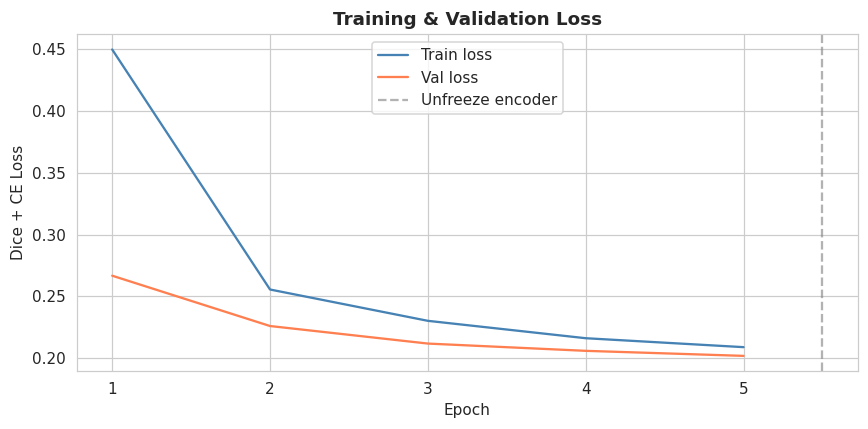

In [22]:
# ── Loss curve ───────────────────────────────────────────────────────────────
epochs = range(1, len(history['train_loss']) + 1)
phase1_end = CONFIG['phase1_epochs']

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, history['train_loss'], label='Train loss', color='steelblue')
ax.plot(epochs, history['val_loss'],   label='Val loss',   color='coral')
ax.axvline(phase1_end + 0.5, ls='--', color='grey', alpha=0.6, label='Unfreeze encoder')
ax.set_xlabel('Epoch')
ax.set_ylabel('Dice + CE Loss')
ax.set_title('Training & Validation Loss', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], 'loss_curve.png'), bbox_inches='tight')
plt.show()

## 5. Inference & disease severity quantification

In [23]:
# ── Load best weights ────────────────────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
model.eval()
print('Best model loaded.')

Best model loaded.


In [24]:
# ── Prediction + quantification helper ───────────────────────────────────────

@torch.no_grad()
def predict_and_quantify(model, image_tensor, device):
    """
    Run inference on a single image and compute disease severity.

    Returns
    -------
    pred_mask : np.ndarray (H, W) with {0, 1, 2}
    metrics   : dict with pixel counts and severity %
    """
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.amp.autocast(device_type=device.type, enabled=USE_AMP):
        output = model(image_tensor)

    pred_mask = torch.argmax(output.squeeze(0), dim=0).cpu().numpy()

    pixels_bg      = int(np.sum(pred_mask == 0))
    pixels_healthy  = int(np.sum(pred_mask == 1))
    pixels_disease  = int(np.sum(pred_mask == 2))
    total_plant     = pixels_healthy + pixels_disease

    severity = (pixels_disease / total_plant * 100) if total_plant > 0 else 0.0

    metrics = {
        'pixels_background': pixels_bg,
        'pixels_healthy':    pixels_healthy,
        'pixels_disease':    pixels_disease,
        'total_plant_area':  total_plant,
        'severity_pct':      round(severity, 2),
    }
    return pred_mask, metrics

print('predict_and_quantify() defined.')

predict_and_quantify() defined.


In [25]:
# ── Batch inference on validation samples ────────────────────────────────────
N_SAMPLES = 8
rng = random.Random(CONFIG['seed'])
sample_indices = rng.sample(range(len(val_ds)), k=min(N_SAMPLES, len(val_ds)))

sample_images, sample_gt, sample_preds, sample_metrics = [], [], [], []

for idx in sample_indices:
    img_tensor, gt_mask = val_ds[idx]
    pred_mask, metrics  = predict_and_quantify(model, img_tensor, DEVICE)

    sample_images.append(img_tensor)
    sample_gt.append(gt_mask.numpy())
    sample_preds.append(pred_mask)
    sample_metrics.append(metrics)

    print(f'Sample {idx:>5d}  |  Severity: {metrics["severity_pct"]:6.2f}%  '
          f'|  Plant area: {metrics["total_plant_area"]:,} px  '
          f'|  Diseased: {metrics["pixels_disease"]:,} px')

Sample 10476  |  Severity:  13.57%  |  Plant area: 26,090 px  |  Diseased: 3,541 px
Sample  1824  |  Severity:   2.17%  |  Plant area: 37,940 px  |  Diseased: 823 px
Sample   409  |  Severity:   0.01%  |  Plant area: 39,356 px  |  Diseased: 2 px
Sample  4506  |  Severity:  61.71%  |  Plant area: 17,206 px  |  Diseased: 10,618 px
Sample  4012  |  Severity:   2.42%  |  Plant area: 18,860 px  |  Diseased: 457 px
Sample  3657  |  Severity:   5.12%  |  Plant area: 23,319 px  |  Diseased: 1,194 px
Sample  2286  |  Severity:   2.11%  |  Plant area: 35,893 px  |  Diseased: 759 px
Sample  1679  |  Severity:   7.34%  |  Plant area: 27,255 px  |  Diseased: 2,000 px


## 6. Visualisation: original → ground truth → prediction

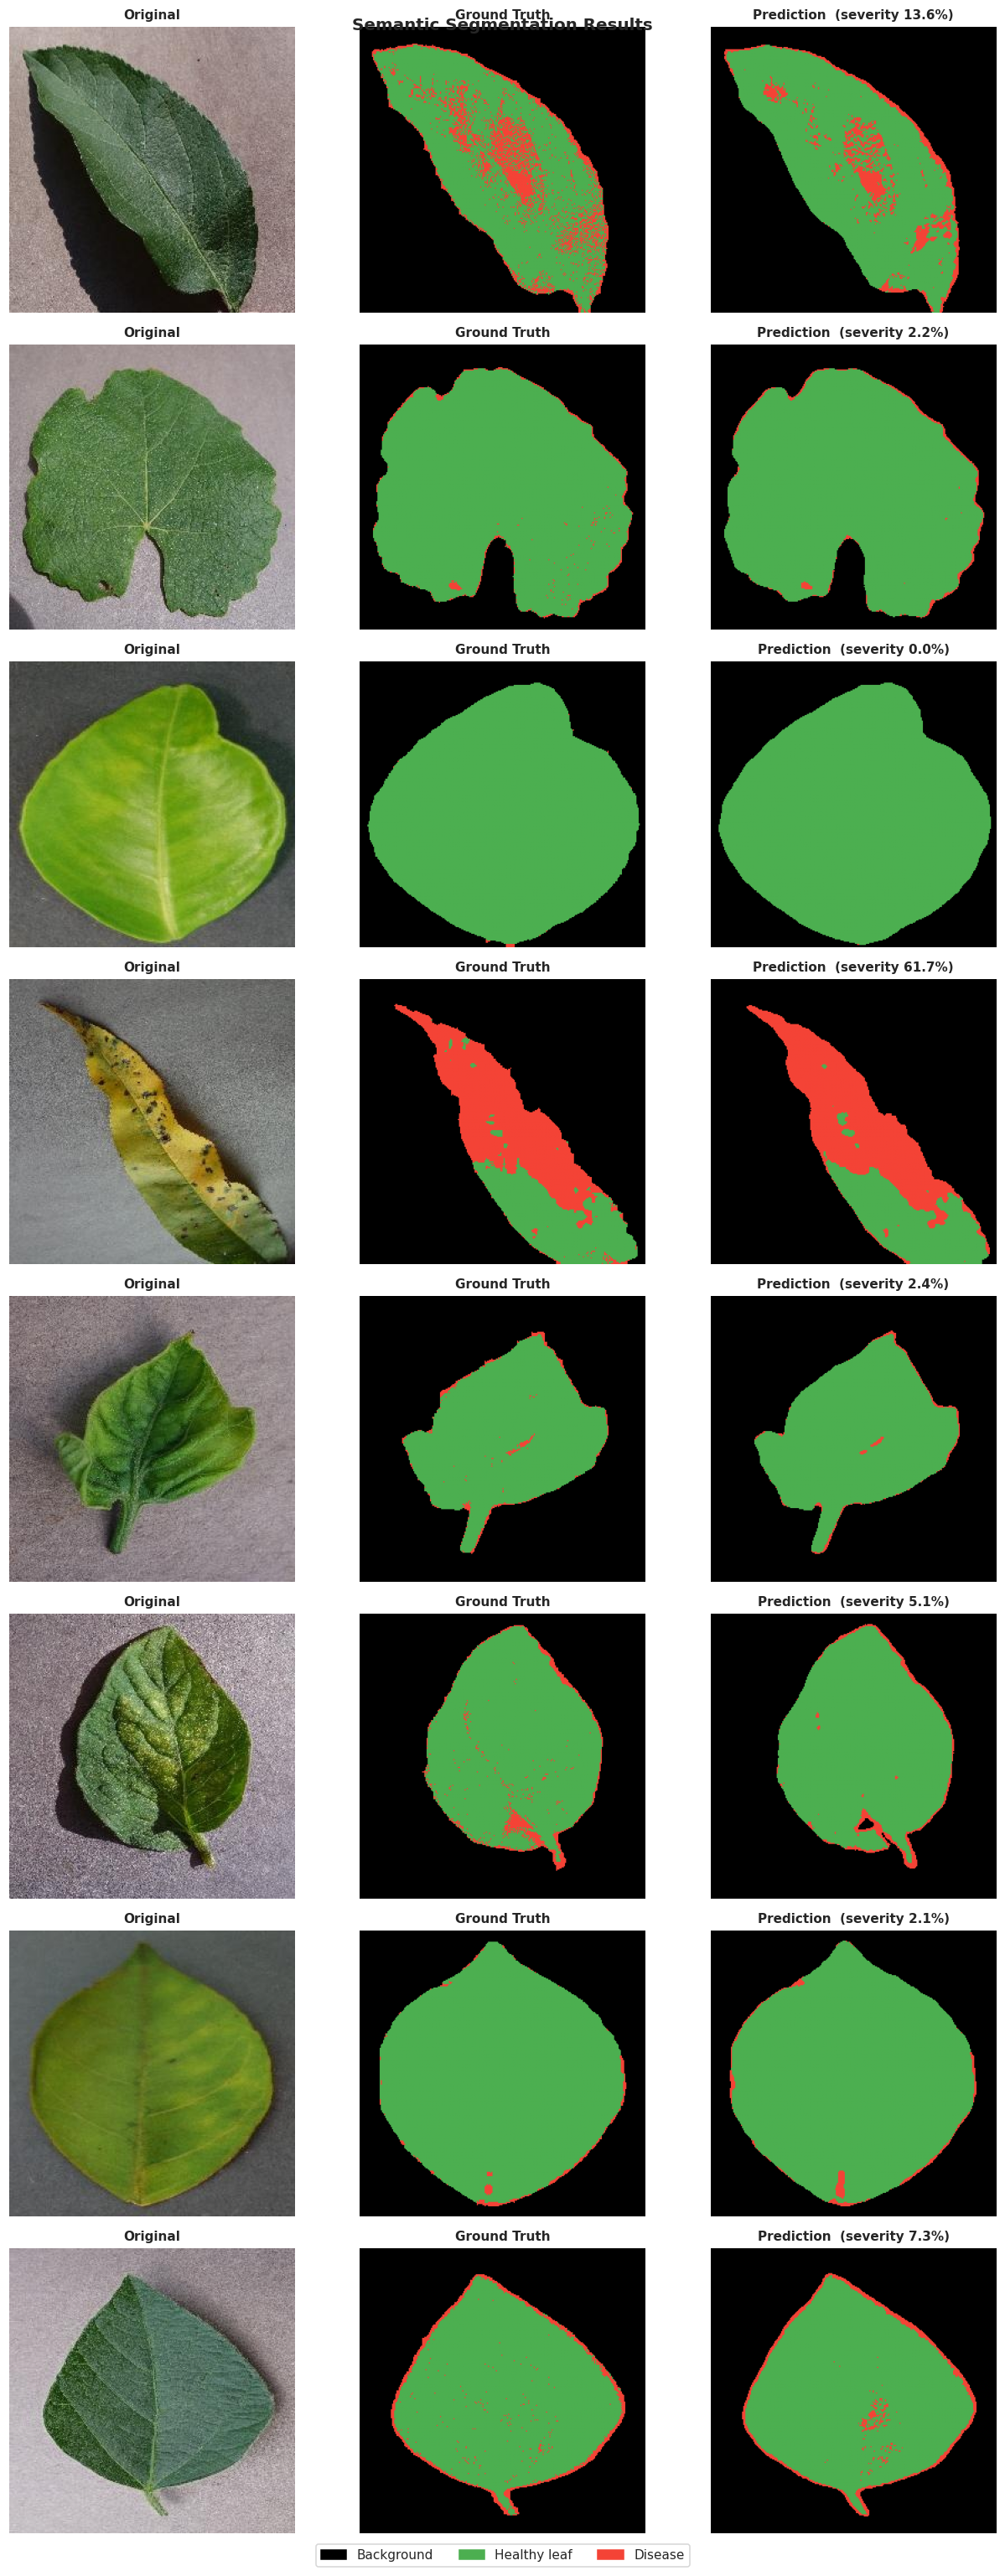

In [26]:
# ── Side-by-side comparison ──────────────────────────────────────────────────
MASK_CMAP = ListedColormap(['black', '#4CAF50', '#F44336'])   # bg, healthy, disease
legend_patches = [
    mpatches.Patch(color='black',   label='Background'),
    mpatches.Patch(color='#4CAF50', label='Healthy leaf'),
    mpatches.Patch(color='#F44336', label='Disease'),
]

n_rows = len(sample_images)
fig, axes = plt.subplots(n_rows, 3, figsize=(12, 3.5 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for r in range(n_rows):
    # Original image (de-normalise from tensor)
    img_np = sample_images[r].permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)

    axes[r, 0].imshow(img_np)
    axes[r, 0].set_title('Original', fontsize=10, fontweight='bold')
    axes[r, 0].axis('off')

    axes[r, 1].imshow(sample_gt[r], cmap=MASK_CMAP, vmin=0, vmax=2)
    axes[r, 1].set_title('Ground Truth', fontsize=10, fontweight='bold')
    axes[r, 1].axis('off')

    sev = sample_metrics[r]['severity_pct']
    axes[r, 2].imshow(sample_preds[r], cmap=MASK_CMAP, vmin=0, vmax=2)
    axes[r, 2].set_title(f'Prediction  (severity {sev:.1f}%)',
                         fontsize=10, fontweight='bold')
    axes[r, 2].axis('off')

fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Semantic Segmentation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], 'segmentation_results.png'),
            bbox_inches='tight')
plt.show()

## 7. Summary: disease severity distribution

Inference: 100%|██████████| 200/200 [00:03<00:00, 60.09it/s]


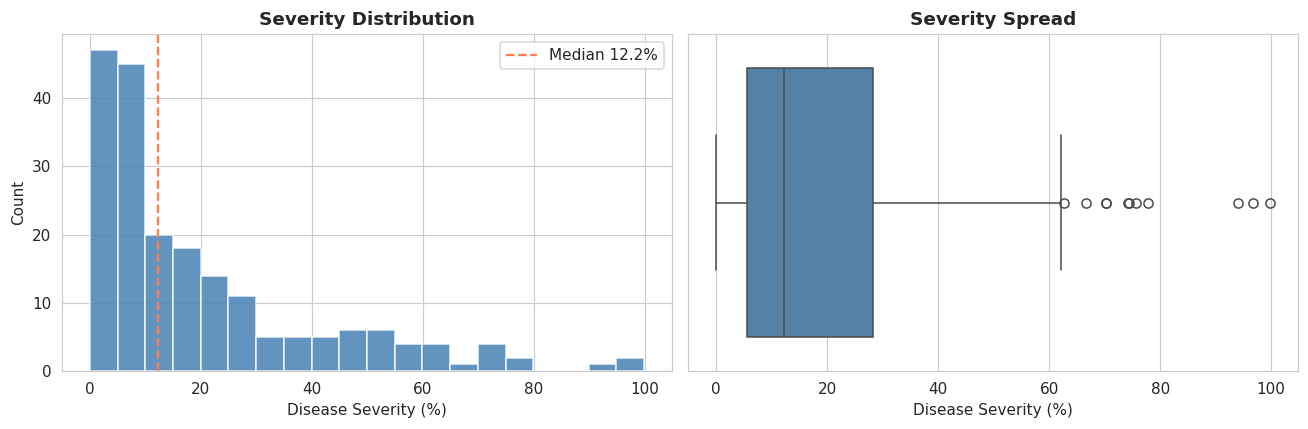


Severity stats (n=200):
  Mean   : 20.43%
  Median : 12.20%
  Std    : 21.11%
  Min    : 0.00%
  Max    : 99.83%


In [27]:
# ── Severity across a larger set of validation images ────────────────────────
MAX_EVAL = min(200, len(val_ds))
eval_indices = rng.sample(range(len(val_ds)), k=MAX_EVAL)

severities = []
for idx in tqdm(eval_indices, desc='Inference'):
    img_tensor, _ = val_ds[idx]
    _, metrics = predict_and_quantify(model, img_tensor, DEVICE)
    severities.append(metrics['severity_pct'])

severities = np.array(severities)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(severities, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.median(severities), color='coral', ls='--',
                label=f'Median {np.median(severities):.1f}%')
axes[0].set_xlabel('Disease Severity (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Severity Distribution', fontweight='bold')
axes[0].legend()

# Box plot
sns.boxplot(x=severities, ax=axes[1], color='steelblue')
axes[1].set_xlabel('Disease Severity (%)')
axes[1].set_title('Severity Spread', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], 'severity_distribution.png'),
            bbox_inches='tight')
plt.show()

print(f'\nSeverity stats (n={MAX_EVAL}):')
print(f'  Mean   : {severities.mean():.2f}%')
print(f'  Median : {np.median(severities):.2f}%')
print(f'  Std    : {severities.std():.2f}%')
print(f'  Min    : {severities.min():.2f}%')
print(f'  Max    : {severities.max():.2f}%')

---

**Resumo**: Uma U-Net com encoder MobileNetV2 foi ajustada (*fine-tuned*) para segmentar imagens de folhas do PlantVillage em: fundo, tecido saudável e tecido doente. As predições ao nível de pixel são convertidas em uma **porcentagem de severidade da doença** — uma métrica prática que traduz a saída do *deep learning* em um indicador agronômico acionável.

**Principais decisões de projeto**:
- *Encoder leve* — O MobileNetV2 permite inferência em tempo real em dispositivos de borda (*edge devices*)
- *Loss combinada (Dice + CE)* — Aborda o desequilíbrio severo de classes (pixels de doença ≪ fundo)
- *Ground truth derivado de HSV* — Evita a necessidade de anotação manual ao nível de pixel
- *Treinamento em duas fases* — Aproveita os recursos do ImageNet enquanto se adapta à imagética de plantas